In [8]:
import pandas as pd

In [9]:
# construindo o dataframe
data = {
    'age': [22, 25, 32, 19, 17, 18, 45, 55, 45, 70],
    'income': [2500, 3100, 1800, 1450, 5000, 10000, 7500, 9500, 16000, 18000],
    'sex': ['M', 'F', 'M', 'F', 'M', 'M', 'M', 'F', 'F', 'M'],
    'city': ['SP', 'MG', 'BA', 'CE', 'SP', 'SP', 'MG', 'SP', 'RJ', 'RJ']
}

df = pd.DataFrame(data)

In [10]:
df

,age,income,sex,city
0,22,2500,M,SP
1,25,3100,F,MG
2,32,1800,M,BA
3,19,1450,F,CE
4,17,5000,M,SP
5,18,10000,M,SP
6,45,7500,M,MG
7,55,9500,F,SP
8,45,16000,F,RJ
9,70,18000,M,RJ


## Como alterar apenas uma(s) coluna(s) com algumas condições 
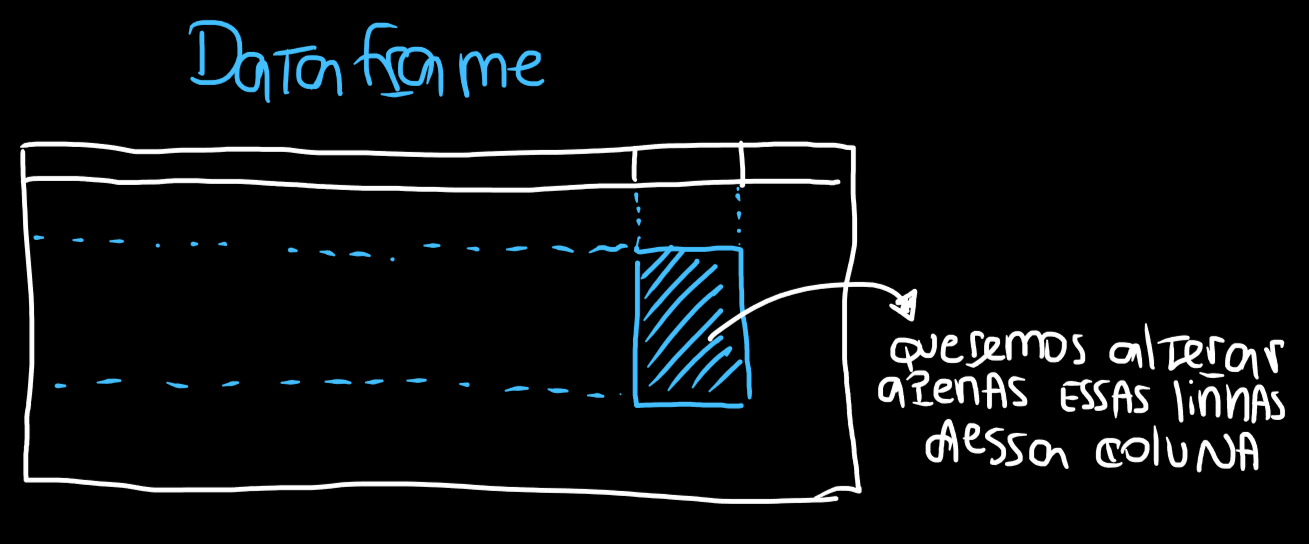

No pandas siga o seguinte esquema:
```python
df.loc[row_condtions, columns] = new_values

# por exemplo

df.loc[mask, ['col_a', 'col_b']] = ['value_col_a', 'value_col_b']
```

In [15]:
# queremos alterar todo mundo que tem menos de 55 anos e que tem sexo feminino para morar em PA
mask = (df['age'] < 55) & (df['sex'] == 'F')  # essa é nossa row_conditions
df.loc[mask, 'city'] = 'PA'  # aqui alteramos o valor no dataframe

In [16]:
df

,age,income,sex,city
0,22,2500,M,SP
1,25,3100,F,PA
2,32,1800,M,BA
3,19,1450,F,PA
4,17,5000,M,SP
5,18,10000,M,SP
6,45,7500,M,MG
7,55,9500,F,SP
8,45,16000,F,PA
9,70,18000,M,RJ


# Como passar uma função em uma Coluna

In [11]:
def divide_by(value: str, by: int = 2):
    return value / by

df['income'].apply(lambda x: divide_by(x, by=1000))

0     2.50
1     3.10
2     1.80
3     1.45
4     5.00
5    10.00
6     7.50
7     9.50
8    16.00
9    18.00
Name: income, dtype: float64

In [12]:
df['income'] / 1000

0     2.50
1     3.10
2     1.80
3     1.45
4     5.00
5    10.00
6     7.50
7     9.50
8    16.00
9    18.00
Name: income, dtype: float64

# Como passar uma função usando mais de uma Coluna

In [17]:
def mul_two_cols(value_a: int, value_b: int):
    return value_a * value_b

# precisamos do row para explicitar que estamos nas colunas
df.apply(lambda row: mul_two_cols(row['age'], row['income']), axis=1)

0      55000
1      77500
2      57600
3      27550
4      85000
5     180000
6     337500
7     522500
8     720000
9    1260000
dtype: int64

In [19]:
df['age'] * df['income']

0      55000
1      77500
2      57600
3      27550
4      85000
5     180000
6     337500
7     522500
8     720000
9    1260000
dtype: int64

# Como usar uma função de agregação para criar uma coluna nova usando `transform`

In [22]:
# Criando a coluna média de salario por city dividido pela idade para todas as linhas
df['mean_income_city'] = (
    df.groupby('city')['income']
    .transform('mean')
)
df

,age,income,sex,city,mean_income_city
0,22,2500,M,SP,6750.0
1,25,3100,F,MG,5300.0
2,32,1800,M,BA,1800.0
3,19,1450,F,CE,1450.0
4,17,5000,M,SP,6750.0
5,18,10000,M,SP,6750.0
6,45,7500,M,MG,5300.0
7,55,9500,F,SP,6750.0
8,45,16000,F,RJ,17000.0
9,70,18000,M,RJ,17000.0


In [23]:
(
    df.groupby('city')['income']
    .transform('mean') / df['age']
)

0    306.818182
1    212.000000
2     56.250000
3     76.315789
4    397.058824
5    375.000000
6    117.777778
7    122.727273
8    377.777778
9    242.857143
dtype: float64

# Pivot

In [31]:
# Média de income por cidade e sexo
df.pivot_table(
    index='city',
    columns='sex',
    values='income',
    aggfunc='mean'
).round(1)

sex,F,M
city,,
BA,NaN,1800.0
CE,1450.0,NaN
MG,3100.0,7500.0
RJ,16000.0,18000.0
SP,9500.0,5833.3


In [26]:
# idade média por cidade
df.pivot_table(
    index='city',
    values='age',
    aggfunc='mean'
)

,age
city,
BA,32.0
CE,19.0
MG,35.0
RJ,57.5
SP,28.0


# Melt

In [33]:
df.melt(
    id_vars=['city', 'sex'],
    value_vars=['income', 'age']
)

,city,sex,variable,value
0,SP,M,income,2500
1,MG,F,income,3100
2,BA,M,income,1800
3,CE,F,income,1450
4,SP,M,income,5000
5,SP,M,income,10000
6,MG,M,income,7500
7,SP,F,income,9500
8,RJ,F,income,16000
9,RJ,M,income,18000


# Crosstab

In [34]:
pd.crosstab(df['city'], df['sex'])

sex,F,M
city,,
BA,0,1
CE,1,0
MG,1,1
RJ,1,1
SP,1,3


In [38]:
# normalize: all, index, columns
pd.crosstab(df['city'], df['sex'], normalize='all')

sex,F,M
city,,
BA,0.0,0.1
CE,0.1,0.0
MG,0.1,0.1
RJ,0.1,0.1
SP,0.1,0.3


In [39]:
pd.crosstab(df['city'], df['sex'])

sex,F,M
city,,
BA,0,1
CE,1,0
MG,1,1
RJ,1,1
SP,1,3
